# Test IQ FB

## Define a Synchrotron object

In [1]:
import numpy as np
import h5py as hp
import matplotlib.pyplot as plt
from tqdm import tqdm
from mbtrack2 import Synchrotron, Electron, Optics, LongitudinalMap, SynchrotronRadiation

d:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


mbtrack2 version 0.8.0
--------------------------------------------------
If used in a publication, please cite mbtrack2 paper and the zenodo archive for the corresponding code version (and other papers for more specific features).
[1] A. Gamelin, W. Foosang, N. Yamamoto, V. Gubaidulin and R. Nagaoka, “mbtrack2”. Zenodo, Dec. 16, 2024. doi: 10.5281/zenodo.14418989.
[2] A. Gamelin, W. Foosang, and R. Nagaoka, “mbtrack2, a Collective Effect Library in Python”, presented at the 12th Int. Particle Accelerator Conf. (IPAC'21), Campinas, Brazil, May 2021, paper MOPAB070.




In [2]:
h = 20 # Harmonic number of the accelerator.
L = 100 # Ring circumference in [m].
E0 = 1.5e9 # Nominal (total) energy of the ring in [eV].
particle = Electron() # Particle considered.
ac = 1e-3 # Momentum compaction factor.
U0 = 200e3 # Energy loss per turn in [eV].
tau = np.array([1e-3, 1e-3, 2e-3]) # Horizontal, vertical and longitudinal damping times in [s].
tune = np.array([12.2, 15.3]) # Horizontal and vertical tunes.
emit = np.array([10e-9, 10e-12]) # Horizontal and vertical equilibrium emittance in [m.rad].
sigma_0 = 15e-12 # Natural bunch length in [s].
sigma_delta = 1e-3 # Equilibrium energy spread.
chro = [2.0, 3.0] # Horizontal and vertical (non-normalized) chromaticities.

In [3]:
local_beta = np.array([3, 2]) # Beta function at the tracking location.
local_alpha = np.array([0, 0]) # Alpha function at the tracking location.
local_dispersion = np.array([0, 0, 0, 0]) # Dispersion function and its derivative at the tracking location.
optics = Optics(local_beta=local_beta, local_alpha=local_alpha,
                  local_dispersion=local_dispersion)

In [4]:
ring = Synchrotron(h=h, optics=optics, particle=particle, L=L, E0=E0, ac=ac,
                   U0=U0, tau=tau, emit=emit, tune=tune,
                   sigma_delta=sigma_delta, sigma_0=sigma_0, chro=chro)

In [5]:
print("RF frequency = %.5f MHz"%(ring.f1/1e6))
print("Revolution frequency = %.5f MHz"%(ring.f0/1e6))

RF frequency = 59.95849 MHz
Revolution frequency = 2.99792 MHz


In [6]:
long = LongitudinalMap(ring) # define the LongitudinalMap element with the ring parameters
rad = SynchrotronRadiation(ring)

## Define starting parameters

In [7]:
from mbtrack2 import Beam, CavityResonator, CavityMonitor, plot_cavitydata

In [8]:
import os

def restart(I0=0.001, tot_turns=500):
    fill_ptrn = np.zeros(ring.h)
    fill_ptrn[0:ring.h] = I0 / h
    mybeam = Beam(ring)
    mybeam.init_beam(fill_ptrn, mp_per_bunch=1)

    m = 1  # Harmonic number of the cavity
    Rs = 5e6  # Shunt impedance [Ohm]
    Q = 35e3
    QL = 5e3
    detune = -100e3  # Hz
    Ncav = 4
    MC = CavityResonator(ring, m, Rs, Q, QL, detune, Ncav=Ncav)

    MC.Vc = 1e6
    MC.theta = np.arccos(ring.U0 / MC.Vc)
    MC.set_optimal_detune(I0)
    MC.set_generator(I0)

    # 如果 MCmon 已存在，关闭并删除旧 HDF5 文件
    if 'MCmon' in globals():
        try:
            globals()["MCmon"].close()
        except Exception as e:
            print(f"Warning: MCmon close failed: {e}")

    if os.path.exists("save.hdf5"):
        try:
            os.remove("save.hdf5")
        except Exception as e:
            print(f"Warning: Failed to delete save.hdf5: {e}")

    total_size = int(tot_turns / 5)
    MCmon = CavityMonitor("MC", ring, file_name="save",
                          total_size=total_size, save_every=5,
                          buffer_size=10, mpi_mode=False)

    return mybeam, MC, MCmon


# CavityResonator without loop/feedbacks

## Without beam

Before adding loops and feedbacks, we can have a look at the cavity voltage and phase evolution without beam, i.e. a *frozen* beam without beam longitudinal motion and very low current (1 mA):

In [9]:
mybeam, MC, MCmon = restart(I0=0.001)

In [10]:
for i in tqdm(range(500)):
  MC.track(mybeam)
  MCmon.track(mybeam, MC)
meanVc = np.mean(MC.cavity_phasor_record)
print(f"\n Residual error: amplitude {np.round((1-np.abs(meanVc)/MC.Vc)*100,3)} % & phase {np.round((1-np.angle(meanVc)/MC.theta)*100,3)} %")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:09<00:00, 51.42it/s]


 Residual error: amplitude -0.001 % & phase 0.001 %


The `CavityResonator` setpoint (`CavityResonator.Vc` for the amplitude and `CavityResonator.theta` for the phase) can be shown along the data from tracking using the `show_objective=True` option of the `plot_cavitydata` function.

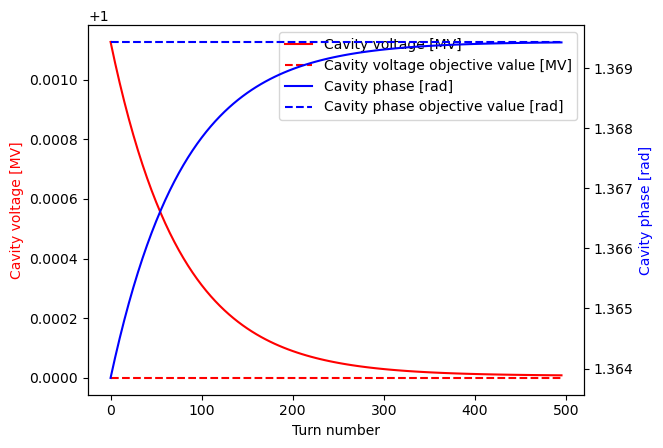

In [11]:
fig = plot_cavitydata("save.hdf5","MC", show_objective=True)

As there is no loop or feedback, the generator voltage/phase is constant:

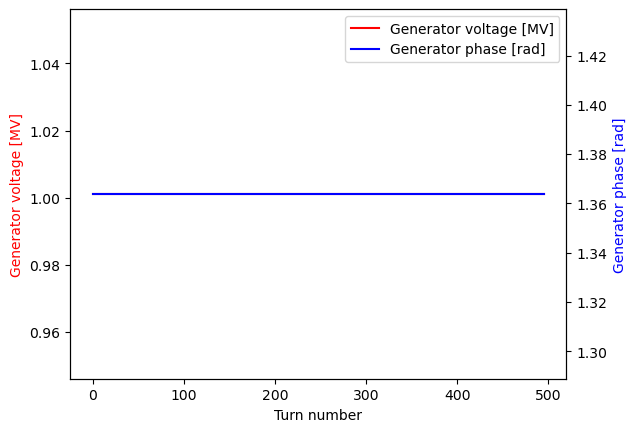

In [12]:
fig = plot_cavitydata("save.hdf5","MC", phasor="generator")

The beam voltage is nearly zero as the current is very low:

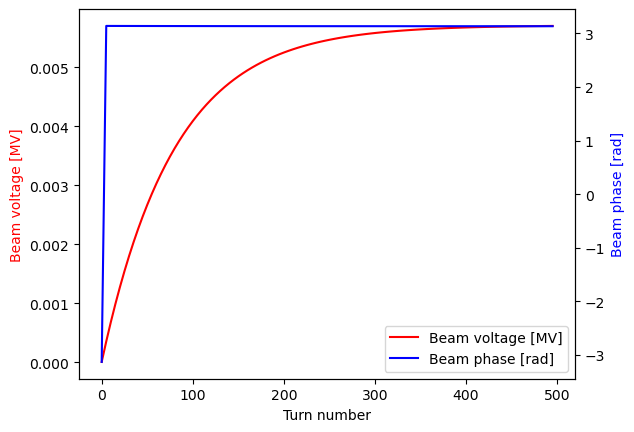

In [13]:
fig = plot_cavitydata("save.hdf5","MC", phasor="beam")

## With beam

When including longtudinal motion and higher current (200 mA), it takes a bit longer for the cavity voltage and phase to converge to its design value as the beam loading needs to build up:

In [14]:
mybeam, MC, MCmon = restart(I0=0.2, tot_turns=3000)

In [15]:
for i in tqdm(range(3000)):
  long.track(mybeam)
  rad.track(mybeam)
  MC.track(mybeam)
  MCmon.track(mybeam, MC)
meanVc = np.mean(MC.cavity_phasor_record)
print(f"\n Residual error: amplitude {np.round((1-np.abs(meanVc)/MC.Vc)*100,3)} % & phase {np.round((1-np.angle(meanVc)/MC.theta)*100,3)} %")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [01:12<00:00, 41.55it/s]


 Residual error: amplitude 0.025 % & phase -0.004 %


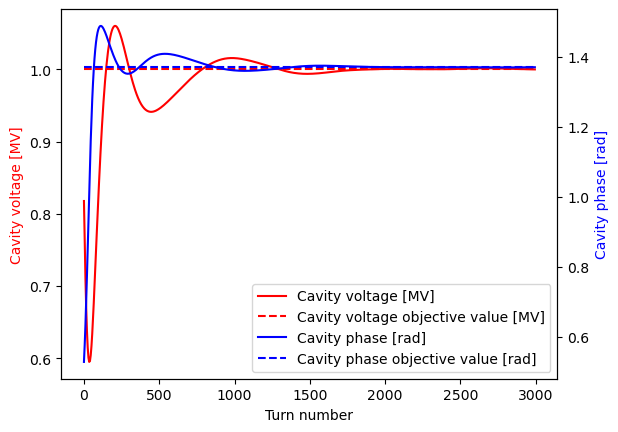

In [16]:
fig = plot_cavitydata("save.hdf5","MC", show_objective=True)

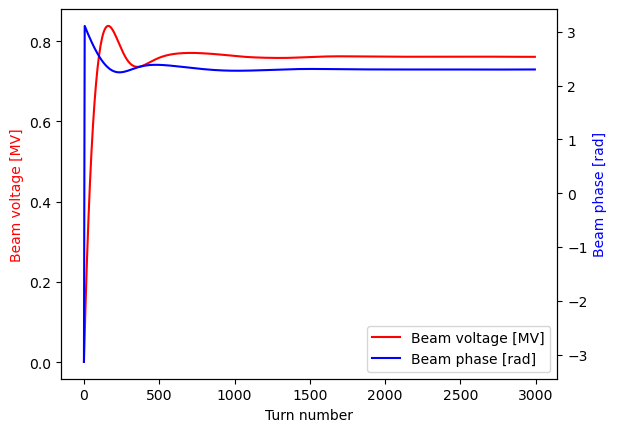

In [17]:
fig = plot_cavitydata("save.hdf5","MC", phasor="beam")

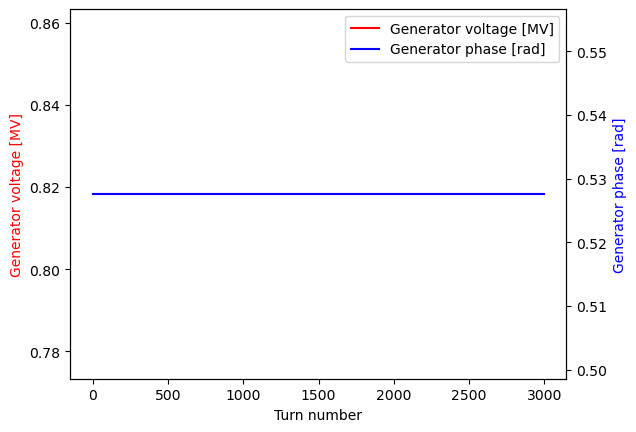

In [18]:
fig = plot_cavitydata("save.hdf5","MC", phasor="generator")

## With beam and phasor initialization

To speed up the beam loading build-up, it is possible to use the `CavityResonator.init_phasor` method to initialize the `CavityResonator.beam_phasor` to its equilibrium value corresponding to a given beam distribution:

In [19]:
mybeam, MC, MCmon = restart(I0=0.2, tot_turns=500)

In [20]:
MC.init_phasor(mybeam)

In [21]:
for i in tqdm(range(500)):
  long.track(mybeam)
  rad.track(mybeam)
  MC.track(mybeam)
  MCmon.track(mybeam, MC)
meanVc = np.mean(MC.cavity_phasor_record)
print(f"\n Residual error: amplitude {np.round((1-np.abs(meanVc)/MC.Vc)*100,3)} % & phase {np.round((1-np.angle(meanVc)/MC.theta)*100,3)} %")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:11<00:00, 42.89it/s]


 Residual error: amplitude -0.182 % & phase 0.14 %


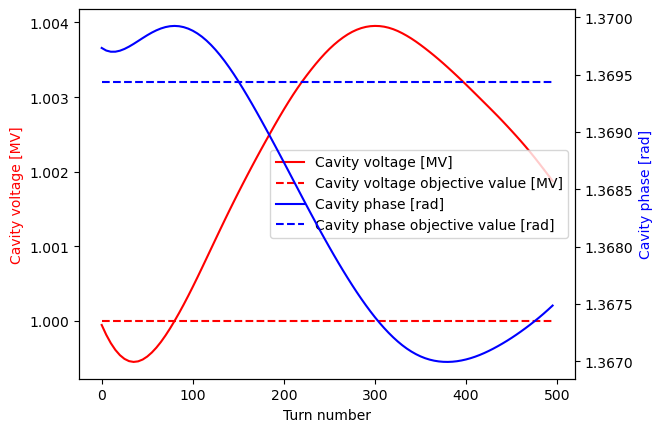

In [22]:
fig = plot_cavitydata("save.hdf5","MC", show_objective=True)

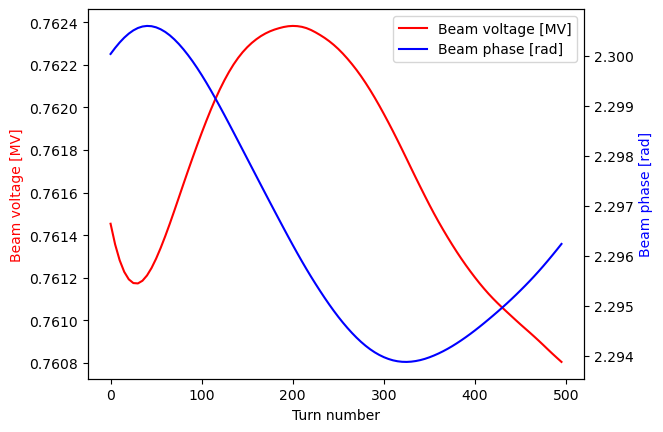

In [23]:
fig = plot_cavitydata("save.hdf5","MC", phasor="beam")

# ProportionalIntegralLoop class

The `ProportionalIntegralLoop` is a **more realistic Proportional Integral (PI) loop** to control a `CavityResonator` amplitude and phase via generator current `Ig` to take into account the cavity response [1].

The basic idea of a PI controller is described here: https://en.wikipedia.org/wiki/PID_controller

The `ProportionalIntegralLoop` should be **initialized only after generator
parameters are set**.

The `ProportionalIntegralLoop` important inputs are:
+ `gain` a list of two float like `[Pain, Igain]`, corresponding to the proportional gain `Pain` and integral gain `Igain` of the feedback.
+ `sample_num`, the number of bunch over which the cavity amplitude and phase is computed (in unit of bucket number).
+ `every`, the time interval between two cavity voltage monitoring and feedback in unit of bucket number. This corresponds to the update rate of the feedback.
+ `delay` the loop delay in unit of bucket number.

The feedback setpoints are `CavityResonator.Vc` and `CavityResonator.theta` and the loop modifies the generator amplitude `CavityResonator.Vg` and phase `CavityResonator.theta_g`.

---

During the `CavityResonator.track` call, at each `every` RF bucket:
+ The `cavity_phasor` is computed as the mean over `sample_num` buckets.
+ The following calculation are done:
  + `diff = (Vc*exp(1j*theta) - cavity_phasor) - FFconst` where `FFconst` is the feedfoward constant.
  + `I_record = I_record + diff/fRF` where `fRF` is the RF frequency.
  + `FB_val = Pain * diff + Igain * I_record`
  + `Ig = Vg2Ig(FB_val) + FFconst` where `Vg2Ig` is a function to go from generator voltage to generator current.
+ `Ig` is applied after `delay` RF buckets.
+ `Ig` is then transformed back to generator voltage and modifies `Vg` and `theta_g`.

See [1] for the description on how to go from `Ig` to `Vg` and opposite.

---

Typical gain values:
+ For normal conducting cavities (QL~1e4), a Pgain of ~1.0 and
Igain of ~1e4(5) are usually used.
+ For super conducting cavity (QL > 1e6), a Pgain of ~100
can be used.

In a "bad" parameter set, an unstable oscillation of the cavity voltage
can be caused. So, a parameter scan of the gain should be made.


Some example parameters for KEK-PF:

FPGA-based LLRF controller, IQ sampling using 8 rf waves, output signal in 77-MHz, around 1us system delay
*   E0=2.5GeV, C=187m, frf=500MHz
*   QL=11800, fs0=23kHz
*   ==> gain=[0.5,1e4], sample_num=8, every=7(13ns), delay=500(1us)

In [24]:
from mbtrack2 import ProportionalIntegralLoop

## Step without beam

The same voltage step is applied using the `ProportionalIntegralLoop` without beam:

In [25]:
mybeam, MC, MCmon = restart(I0=0.001, tot_turns=10000)
MC.init_phasor(mybeam)

In [26]:
PIL = ProportionalIntegralLoop(ring, MC, gain=[1.5, 2e4], sample_num=5, every=5, delay=0)
MC.feedback.append(PIL)

In [27]:
for i in tqdm(range(10000)):
  MC.track(mybeam)
  MCmon.track(mybeam, MC)
  if i == 250:
    MC.Vc = 1.05e6
    MC.theta = np.arccos(ring.U0/MC.Vc)
meanVc = np.mean(MC.cavity_phasor_record)
print(f"\n Residual error: amplitude {np.round((1-np.abs(meanVc)/MC.Vc)*100,3)} % & phase {np.round((1-np.angle(meanVc)/MC.theta)*100,3)} %")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:13<00:00, 51.56it/s]


 Residual error: amplitude -0.002 % & phase -0.005 %


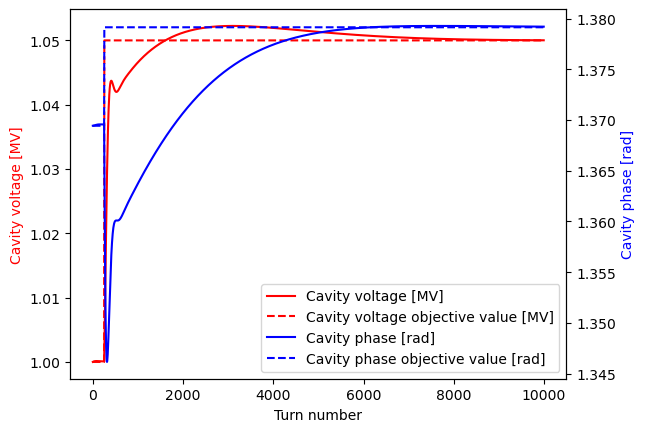

In [28]:
fig = plot_cavitydata("save.hdf5","MC", show_objective=True)

The current generator phasor `Ig` is changed by the `ProportionalIntegralLoop` during the tracking:

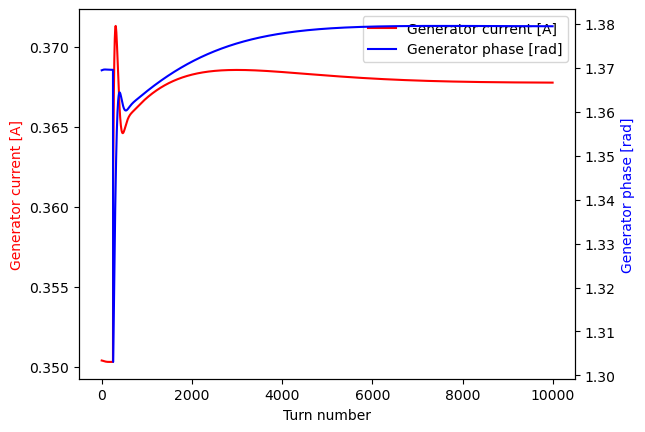

In [29]:
fig = plot_cavitydata("save.hdf5","MC", phasor="ig")

Which induces changes to the generator voltage and phase:

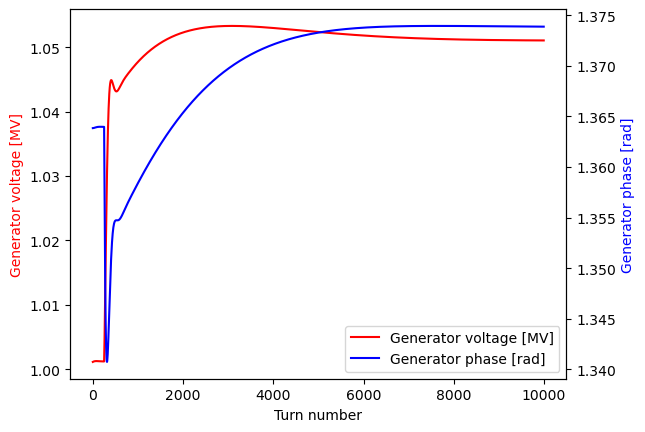

In [30]:
fig = plot_cavitydata("save.hdf5","MC", phasor="generator")

## Step with beam

And now with a 200 mA beam:

In [31]:
mybeam, MC, MCmon = restart(I0=0.2, tot_turns=10000)
MC.init_phasor(mybeam)

In [32]:
PIL = ProportionalIntegralLoop(ring, MC, gain=[0.5, 1e4], sample_num=5, every=5, delay=0)
MC.feedback.append(PIL)

In [33]:
for i in tqdm(range(10000)):
  long.track(mybeam)
  rad.track(mybeam)
  MC.track(mybeam)
  MCmon.track(mybeam, MC)
  if i == 250:
    MC.Vc = 1.05e6
    MC.theta = np.arccos(ring.U0/MC.Vc)
meanVc = np.mean(MC.cavity_phasor_record)
print(f"\n Residual error: amplitude {np.round((1-np.abs(meanVc)/MC.Vc)*100,3)} % & phase {np.round((1-np.angle(meanVc)/MC.theta)*100,3)} %")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:57<00:00, 42.10it/s]


 Residual error: amplitude 0.067 % & phase -0.028 %


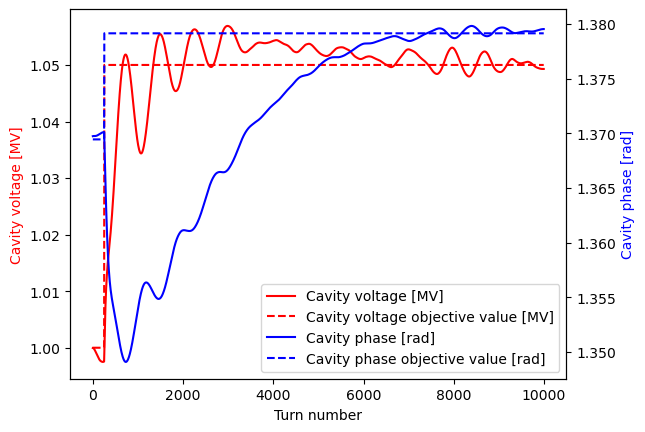

In [34]:
fig = plot_cavitydata("save.hdf5","MC", show_objective=True)

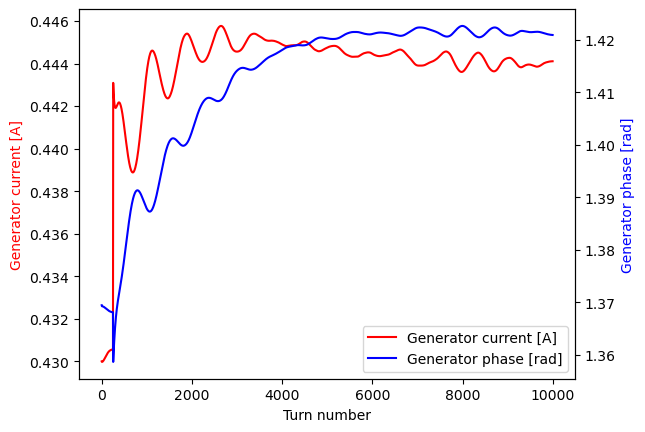

In [35]:
fig = plot_cavitydata("save.hdf5","MC", phasor="ig")

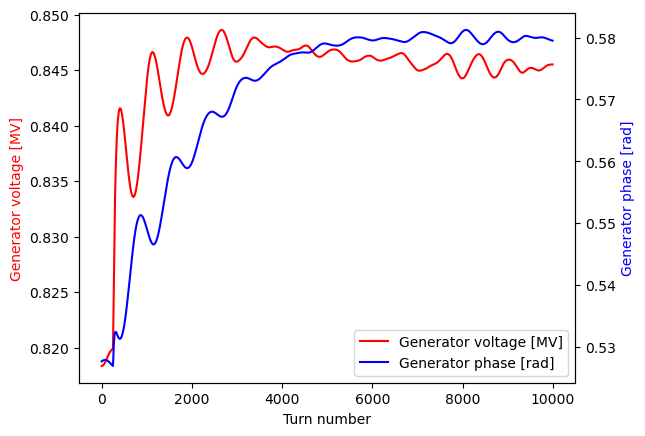

In [36]:
fig = plot_cavitydata("save.hdf5","MC", phasor="generator")

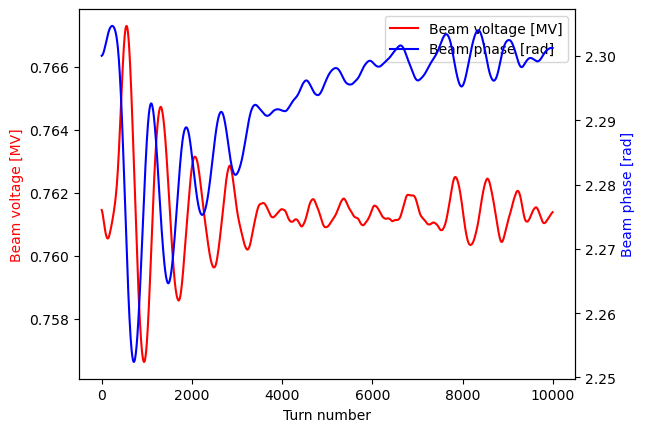

In [37]:
fig = plot_cavitydata("save.hdf5","MC", phasor="beam")

# ProportionalIntegralIQLoopMode0Damper class - Just IQ Proprotional Integral FB

In [38]:
from mbtrack2 import ProportionalIntegralIQLoop

## Step without beam

The same voltage step is applied using the `ProportionalIntegralIQLoopMode0Damper` without beam:

In [39]:
mybeam, MC, MCmon = restart(I0=0.001, tot_turns=10000)
MC.init_phasor(mybeam)

In [40]:
iq_loop = ProportionalIntegralIQLoop(ring, MC, gain=[1, 1e5], 
                                    sample_num=8, every=2, delay=5)
MC.feedback.append(iq_loop)

In [41]:
for i in tqdm(range(10000)):
  MC.track(mybeam)
  MCmon.track(mybeam, MC)
  if i == 250:
    MC.Vc = 1.05e6
    MC.theta = np.arccos(ring.U0/MC.Vc)
    # Update the controller's I/Q reference after changing Vc/theta
    for fb in MC.feedback:
        if hasattr(fb, "update_references"):
            fb.update_references(Vc=MC.Vc, theta=MC.theta)
meanVc = np.mean(MC.cavity_phasor_record)
print(f"\n Residual error: amplitude {np.round((1-np.abs(meanVc)/MC.Vc)*100,3)} % & phase {np.round((1-np.angle(meanVc)/MC.theta)*100,3)} %")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:11<00:00, 52.13it/s]


 Residual error: amplitude 0.0 % & phase 0.0 %


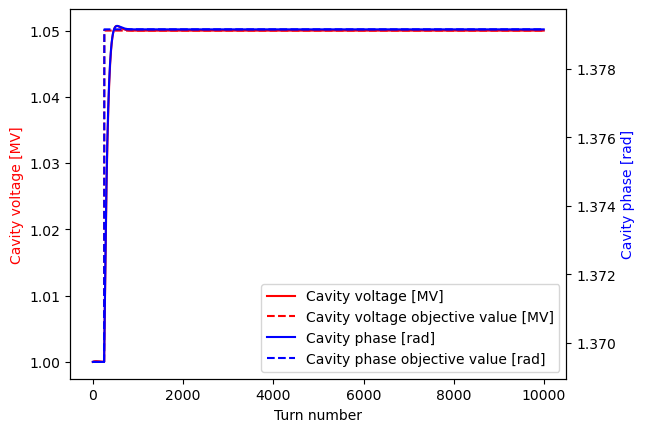

In [42]:
fig = plot_cavitydata("save.hdf5","MC", show_objective=True)

The current generator phasor `Ig` is changed by the `ProportionalIntegralIQLoopMode0Damper` during the tracking:

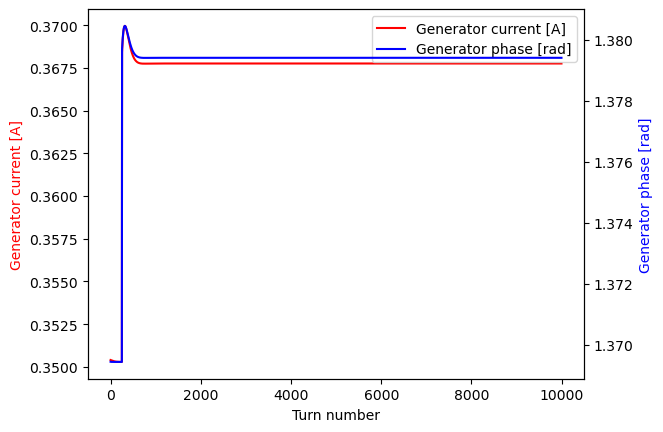

In [43]:
fig = plot_cavitydata("save.hdf5","MC", phasor="ig")

Which induces changes to the generator voltage and phase:

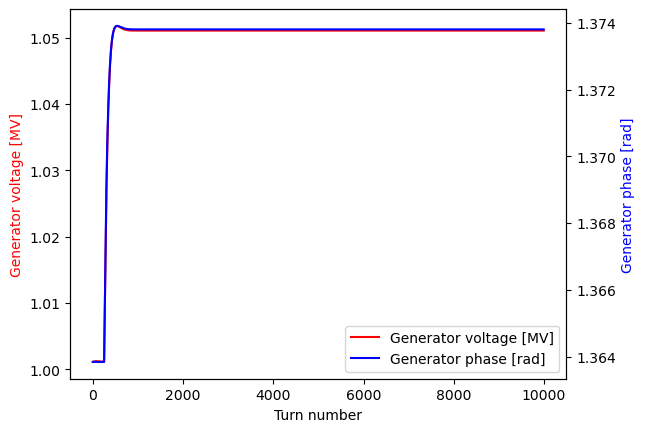

In [17]:
fig = plot_cavitydata("save.hdf5","MC", phasor="generator")

## Step with beam

And now with a 200 mA beam:

In [18]:
mybeam, MC, MCmon = restart(I0=0.2, tot_turns=10000)
MC.init_phasor(mybeam)

In [19]:
iq_loop = ProportionalIntegralIQLoop(ring, MC, gain=[5, 1000], 
                                    sample_num=8, every=2, delay=1)
MC.feedback.append(iq_loop)

In [20]:
for i in tqdm(range(10000)):
  long.track(mybeam)
  rad.track(mybeam)
  MC.track(mybeam)
  MCmon.track(mybeam, MC)
  if i == 250:
    MC.Vc = 1.05e6
    MC.theta = np.arccos(ring.U0/MC.Vc)
    # Update the controller's I/Q reference after changing Vc/theta
    for fb in MC.feedback:
        if hasattr(fb, "update_references"):
            fb.update_references(Vc=MC.Vc, theta=MC.theta)
meanVc = np.mean(MC.cavity_phasor_record)
print(f"\n Residual error: amplitude {np.round((1-np.abs(meanVc)/MC.Vc)*100,3)} % & phase {np.round((1-np.angle(meanVc)/MC.theta)*100,3)} %")

100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:45<00:00, 60.51it/s]


 Residual error: amplitude 0.61 % & phase 0.08 %


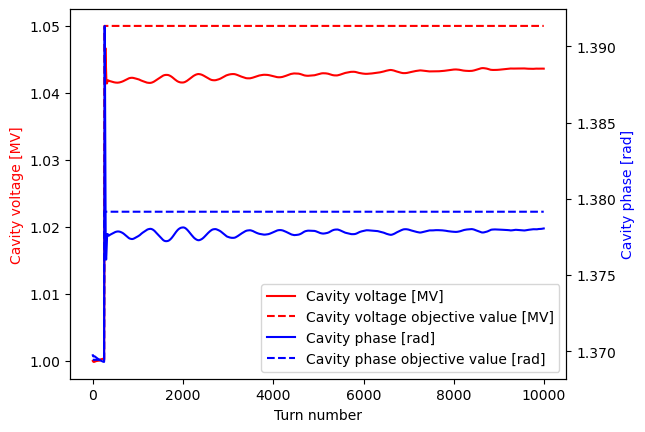

In [21]:
fig = plot_cavitydata("save.hdf5","MC", show_objective=True)

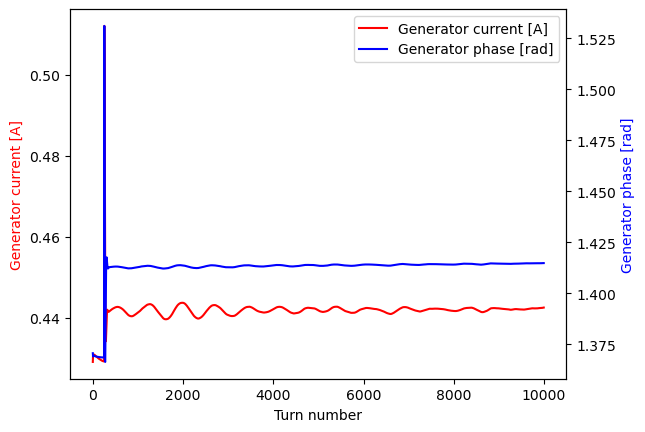

In [22]:
fig = plot_cavitydata("save.hdf5","MC", phasor="ig")

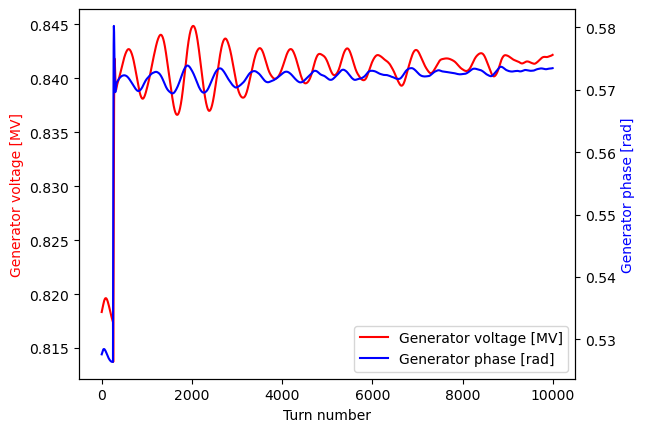

In [23]:
fig = plot_cavitydata("save.hdf5","MC", phasor="generator")

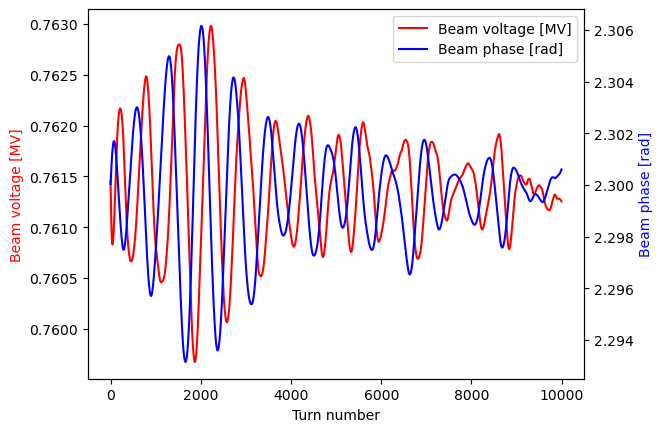

In [24]:
fig = plot_cavitydata("save.hdf5","MC", phasor="beam")

## Step without beam - larger gain I

The same voltage step is applied using the `ProportionalIntegralIQLoopMode0Damper` without beam:

In [ ]:
mybeam, MC, MCmon = restart(I0=0.001, tot_turns=10000)
MC.init_phasor(mybeam)

In [ ]:
PIL = ProportionalIntegralIQLoopMode0Damper(ring, MC, gain=[10, 2e4], sample_num=5, every=5, delay=0)
MC.feedback.append(PIL)

In [ ]:
for i in tqdm(range(10000)):
  MC.track(mybeam)
  MCmon.track(mybeam, MC)
  if i == 250:
    MC.Vc = 1.05e6
    MC.theta = np.arccos(ring.U0/MC.Vc)
meanVc = np.mean(MC.cavity_phasor_record)
print(f"\n Residual error: amplitude {np.round((1-np.abs(meanVc)/MC.Vc)*100,3)} % & phase {np.round((1-np.angle(meanVc)/MC.theta)*100,3)} %")

In [ ]:
fig = plot_cavitydata("save.hdf5","MC", show_objective=True)

The current generator phasor `Ig` is changed by the `ProportionalIntegralIQLoopMode0Damper` during the tracking:

In [ ]:
fig = plot_cavitydata("save.hdf5","MC", phasor="ig")

Which induces changes to the generator voltage and phase:

In [ ]:
fig = plot_cavitydata("save.hdf5","MC", phasor="generator")

## Step without beam - larger gain Q

The same voltage step is applied using the `ProportionalIntegralIQLoopMode0Damper` without beam:

In [ ]:
mybeam, MC, MCmon = restart(I0=0.001, tot_turns=10000)
MC.init_phasor(mybeam)

In [ ]:
PIL = ProportionalIntegralIQLoopMode0Damper(ring, MC, gain=[10, 2e6], sample_num=5, every=5, delay=0)
MC.feedback.append(PIL)

In [ ]:
for i in tqdm(range(10000)):
  MC.track(mybeam)
  MCmon.track(mybeam, MC)
  if i == 250:
    MC.Vc = 1.05e6
    MC.theta = np.arccos(ring.U0/MC.Vc)
meanVc = np.mean(MC.cavity_phasor_record)
print(f"\n Residual error: amplitude {np.round((1-np.abs(meanVc)/MC.Vc)*100,3)} % & phase {np.round((1-np.angle(meanVc)/MC.theta)*100,3)} %")

In [ ]:
fig = plot_cavitydata("save.hdf5","MC", show_objective=True)

The current generator phasor `Ig` is changed by the `ProportionalIntegralIQLoopMode0Damper` during the tracking:

In [ ]:
fig = plot_cavitydata("save.hdf5","MC", phasor="ig")

Which induces changes to the generator voltage and phase:

In [ ]:
fig = plot_cavitydata("save.hdf5","MC", phasor="generator")